In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import KBinsDiscretizer
import warnings
from sklearn.decomposition import PCA
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import SelectKBest, f_classif

In [2]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

train = pd.read_csv("train.csv")
X = train.drop(columns=["class"])
y = train["class"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


from sklearn.model_selection import cross_validate

def evaluate(model, X, y):

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        return_train_score=True
    )
    val_mean = scores["test_score"].mean()
    val_std = scores["test_score"].std()
    train_mean = scores["train_score"].mean()

    return val_mean, val_std, train_mean    


In [3]:
from sklearn.ensemble import RandomForestClassifier

for n_estimators in [100, 200, 300]:
    for max_depth in [None, 10, 20]:
        rf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )
        mean, std, train = evaluate(rf, X, y)
        print(f"n={n_estimators} depth={max_depth} → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

n=100 depth=None → Train: 1.0000 | CV: 0.8160 ± 0.0183
n=100 depth=10 → Train: 0.9970 | CV: 0.8060 ± 0.0263
n=100 depth=20 → Train: 1.0000 | CV: 0.8160 ± 0.0183
n=200 depth=None → Train: 1.0000 | CV: 0.8300 ± 0.0243
n=200 depth=10 → Train: 0.9978 | CV: 0.8130 ± 0.0218
n=200 depth=20 → Train: 1.0000 | CV: 0.8300 ± 0.0243
n=300 depth=None → Train: 1.0000 | CV: 0.8300 ± 0.0221
n=300 depth=10 → Train: 0.9975 | CV: 0.8200 ± 0.0145
n=300 depth=20 → Train: 1.0000 | CV: 0.8300 ± 0.0221


In [4]:
from sklearn.ensemble import RandomForestClassifier

for max_features in ["sqrt", "log2", 0.3]:
    for min_samples_leaf in [1, 3, 5, 10]:
        rf = RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            max_features=max_features,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        mean, std, train = evaluate(rf, X, y)
        print(f"feat={max_features} leaf={min_samples_leaf} → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

feat=sqrt leaf=1 → Train: 1.0000 | CV: 0.8300 ± 0.0243
feat=sqrt leaf=3 → Train: 0.9943 | CV: 0.8150 ± 0.0192
feat=sqrt leaf=5 → Train: 0.9790 | CV: 0.8200 ± 0.0195
feat=sqrt leaf=10 → Train: 0.9427 | CV: 0.8280 ± 0.0220
feat=log2 leaf=1 → Train: 1.0000 | CV: 0.8200 ± 0.0207
feat=log2 leaf=3 → Train: 0.9948 | CV: 0.8240 ± 0.0248
feat=log2 leaf=5 → Train: 0.9843 | CV: 0.8150 ± 0.0158
feat=log2 leaf=10 → Train: 0.9517 | CV: 0.8200 ± 0.0207
feat=0.3 leaf=1 → Train: 1.0000 | CV: 0.8240 ± 0.0146
feat=0.3 leaf=3 → Train: 0.9950 | CV: 0.8200 ± 0.0167
feat=0.3 leaf=5 → Train: 0.9745 | CV: 0.8120 ± 0.0229
feat=0.3 leaf=10 → Train: 0.9323 | CV: 0.8120 ± 0.0238


### ANALISIS EXHAUSTIVO

Mejor config: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_samples': 1.0, 'max_features': 'sqrt', 'max_depth': None}
Mejor CV: 0.8290


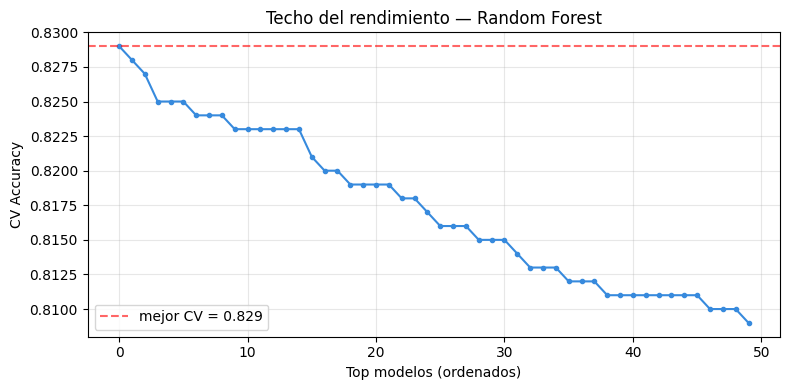

Mejor config: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_samples': 1.0, 'max_features': 'sqrt', 'max_depth': None}
Mejor CV: 0.8290


In [15]:
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20],
    "max_features": ["sqrt", "log2", 0.3],
    "min_samples_leaf": [1, 3, 5, 10],
    "min_samples_split": [2, 5, 10, 20],
    "max_samples": [0.5, 0.7, 0.8, 1.0],
}

grid = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    n_iter=50,
    cv=cv,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)
grid.fit(X, y)

print(f"Mejor config: {grid.best_params_}")
print(f"Mejor CV: {grid.best_score_:.4f}")


# Gráfica de saturación
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(grid.cv_results_)
top100 = results["mean_test_score"].sort_values(ascending=False).head(100).reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(top100, marker="o", markersize=3, color="#378ADD")
plt.axhline(y=grid.best_score_, color="red", linestyle="--", alpha=0.6,
            label=f"mejor CV = {grid.best_score_:.3f}")
plt.xlabel("Top modelos (ordenados)")
plt.ylabel("CV Accuracy")
plt.title("Techo del rendimiento — Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mejor config: {grid.best_params_}")
print(f"Mejor CV: {grid.best_score_:.4f}")

### MODELO FINAL

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    max_features="sqrt",
    min_samples_leaf=10,
    min_samples_split=5,
    max_samples=1.0,
    criterion="gini",
    random_state=42,
    bootstrap=True
)

mean, std, train = evaluate(rf_final, X, y)
print(f"Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

Train: 0.9437 | CV: 0.8290 ± 0.0185
